<table style="width:100%">
<tr>
<td style="vertical-align:middle; text-align:left;">
<font size="2">
<a href="https://sebastianraschka.com">Sebastian Raschka</a> 所著《<a href="https://mng.bz/lZ5B">从零开始构建推理模型</a>》一书的补充代码<br>
<br>代码仓库：<a href="https://github.com/rasbt/reasoning-from-scratch">https://github.com/rasbt/reasoning-from-scratch</a>
</font>
</td>
<td style="vertical-align:middle; text-align:left;">
<a href="https://mng.bz/lZ5B"><img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/cover-small.webp" width="100px"></a>
</td>
</tr>
</table>

# 第四章：通过推理时扩展提升推理能力

本笔记本中正在使用的包：

In [1]:
from importlib.metadata import version

used_libraries = [
    "matplotlib",
    "reasoning_from_scratch",
    "torch",
    "tokenizers"  # Used by reasoning_from_scratch
]

for lib in used_libraries:
    print(f"{lib} version: {version(lib)}")

matplotlib version: 3.10.8
reasoning_from_scratch version: 0.1.13
torch version: 2.9.1
tokenizers version: 0.22.2


<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch04/CH04_F01_raschka.webp" width=600>

&nbsp;
## 4.1 推理时缩放简介

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch04/CH04_F02_raschka.webp" width=600>

- 上图灵感来源于 OpenAI o1 博客文章，https://openai.com/index/learning-to-reason-with-llms/

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch04/CH04_F03_raschka.webp" width=600>

- 所有三种方法在MATH-500基准测试（上一章介绍的基准）上均将基础模型的准确率提升了一倍以上
- 方法1和方法2将在本章介绍；方法3将在下一章介绍

&nbsp;
## 4.2 加载预训练模型

- 模型加载代码类似于第2章和第3章

In [2]:
import torch
from reasoning_from_scratch.ch02 import get_device
from reasoning_from_scratch.ch03 import (
     load_model_and_tokenizer
)

device = get_device()

# Use CPU for the first run of this chapter
device = torch.device("cpu")

model, tokenizer = load_model_and_tokenizer(
    which_model="base",
    device=device,
    use_compile=False
)

Using Apple Silicon GPU (MPS)
✓ qwen3/qwen3-0.6B-base.pth already up-to-date


- 让我们尝试用MATH-500数据集中的一个提示来测试模型，这是我们在上一章中使用过的：

In [3]:
from reasoning_from_scratch.ch03 import render_prompt

raw_prompt = (
    "Half the value of $3x-9$ is $x+37$. "
    "What is the value of $x$?"
)
prompt = render_prompt(raw_prompt)

print(prompt)

You are a helpful math assistant.
Answer the question and write the final result on a new line as:
\boxed{ANSWER}

Question:
Half the value of $3x-9$ is $x+37$. What is the value of $x$?

Answer:


- 以下函数基于前一章的 `generate_text_stream_concat`，但我们对其稍作修改，以便后续能够传入其他 `generate_*` 函数

In [4]:
from reasoning_from_scratch.ch02 import generate_text_basic_stream_cache


def generate_text_stream_concat_flex(
    model, tokenizer, prompt, device, max_new_tokens,
    verbose=False, 
    generate_func=None,  # New
    **generate_kwargs  # New
):

    if generate_func is None:  # New
        generate_func = generate_text_basic_stream_cache
        
    input_ids = torch.tensor(
        tokenizer.encode(prompt), device=device
        ).unsqueeze(0)

    generated_ids = []
    for token in generate_func(  # New
        model=model,
        token_ids=input_ids,
        max_new_tokens=max_new_tokens,
        eos_token_id=tokenizer.eos_token_id,
        **generate_kwargs,  # New
    ):
        next_token_id = token.squeeze(0)
        generated_ids.append(next_token_id.item())

        if verbose:
            print(
                tokenizer.decode(next_token_id.tolist()),
                end="",
                flush=True
            )
    return tokenizer.decode(generated_ids)

In [5]:
response = generate_text_stream_concat_flex(
    model, tokenizer, prompt, device,
    max_new_tokens=2048, verbose=True,
    generate_func=generate_text_basic_stream_cache  # NEW
)

 \boxed{20}

- 顺便说一下，正确答案是83

&nbsp;
## 4.3 使用思维链（Chain-of-Thought）提示生成更优响应

- 提升模型性能的一种经典方法是修改提示词，以鼓励模型逐步思考或解释

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch04/CH04_F04_raschka.webp" width=600>

In [6]:
prompt_cot = prompt + " \n\nExplain step by step."

response_cot = generate_text_stream_concat_flex(
    model, tokenizer, prompt_cot, device,
    max_new_tokens=2048, verbose=True,
)

 To solve the problem, we need to find the value of \( x \) such that half the value of \( 3x - 9 \) is equal to \( x + 37 \).

### Step 1: Set up the equation
We are given that half the value of \( 3x - 9 \) is equal to \( x + 37 \). This can be written as:
\[
\frac{1}{2}(3x - 9) = x + 37
\]

### Step 2: Eliminate the fraction
To eliminate the fraction, multiply both sides of the equation by 2:
\[
2 \cdot \frac{1}{2}(3x - 9) = 2(x + 37)
\]
Simplifying both sides:
\[
3x - 9 = 2x + 74
\]

### Step 3: Solve for \( x \)
Subtract \( 2x \) from both sides to isolate \( x \):
\[
3x - 2x - 9 = 74
\]
Simplify:
\[
x - 9 = 74
\]
Add 9 to both sides to solve for \( x \):
\[
x = 74 + 9
\]
\[
x = 83
\]

### Final Answer:
\[
\boxed{83}
\]

&nbsp;
## 4.4 使用温度缩放控制输出多样性

- 到目前为止，我们一直使用确定性解码；本节将介绍随机解码
- 我们从温度缩放开始，随后在第4.5节中，我们将引入top-p以更好地平衡随机性与连贯性

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch04/CH04_F05_raschka.webp" width=600>

&nbsp;
### 4.4.1 理解选择下一个token的过程

In [7]:
ex_prompt = "The capital of Germany is"

response = generate_text_stream_concat_flex(
    model, tokenizer, ex_prompt, device,
    max_new_tokens=1, verbose=True
)

 Berlin

- 底层运作机制：

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch04/CH04_F06_raschka.webp" width=600>

In [8]:
# 1) Convert input text into token IDs

input_token_ids = torch.tensor(
    tokenizer.encode(ex_prompt), device=device
).unsqueeze(0)

print(input_token_ids)

tensor([[ 785, 6722,  315, 9856,  374]])


In [9]:
# 2) Get scores for next token

with torch.inference_mode():
    next_token_logits = model(input_token_ids)[:, -1]
print(next_token_logits.shape)  # Shape: [1, vocab_size]

torch.Size([1, 151936])


In [10]:
# 3) Find vocabulary index with highest score

max_token_id = torch.argmax(next_token_logits)
print(f"Token ID: {max_token_id}")
print(f"Decoded token: '{tokenizer.decode([max_token_id])}'")

Token ID: 19846
Decoded token: ' Berlin'


- 该LLM的词汇量为151,936个token，token索引范围从0到151,935；我们仅关注索引19,800至19,900之间的100个token子集（便于可视化）

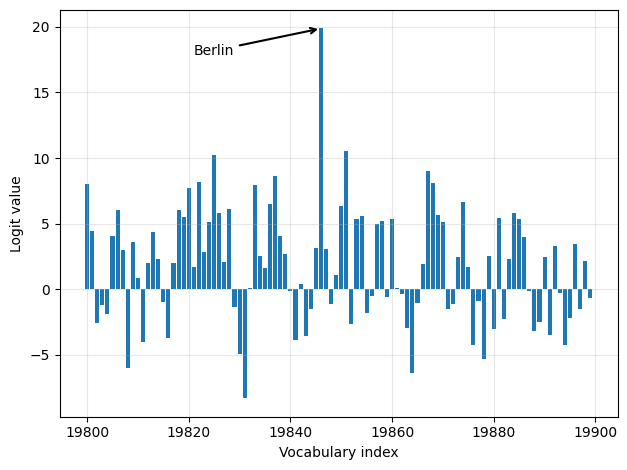

In [11]:
import matplotlib.pyplot as plt

def plot_scores_bar(
    next_token_logits, start=19_800, end=19_900,
    arrow=True, ylabel="Logit value"
):
    # Select vocabulary subsection
    x = torch.arange(start, end)

    # .cpu() is a shortcut for to(torch.device("cpu"))
    logits_section = next_token_logits[0, start:end].float().cpu()

    # Plot logits
    plt.bar(x, logits_section)
    plt.xlabel("Vocabulary index")
    plt.ylabel(ylabel)

    # Highlight max logit
    if arrow:
        max_idx = torch.argmax(logits_section)
        plt.annotate(
            "Berlin",
            xy=(x[max_idx], logits_section[max_idx]),
            xytext=(x[max_idx] - 25, logits_section[max_idx] - 2),
            arrowprops={
                "facecolor": "black", "arrowstyle": "->", "lw": 1.5
            },
            fontsize=10,
        )

    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_scores_bar(next_token_logits)

&nbsp;
### 4.4.2 通过温度参数重新缩放 token 分数（logits）

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch04/CH04_F08_raschka.webp" width=600>

In [12]:
def scale_logits_by_temperature(logits, temperature):
    if temperature <= 0:
        raise ValueError("Temperature must be positive")
    return logits / temperature

- 从技术上讲，使用条形图更好，但折线图更容易看出差异：

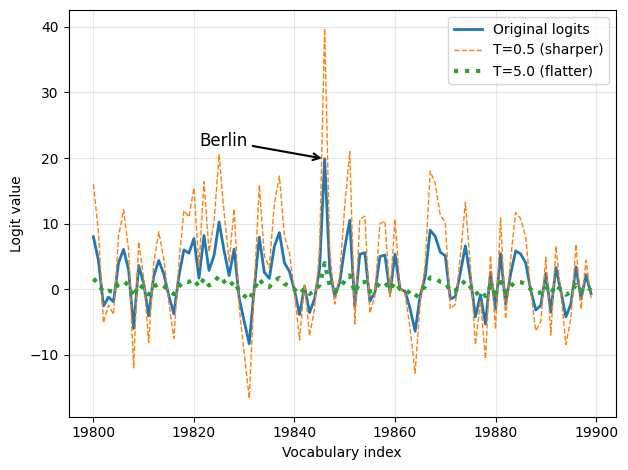

In [13]:
def plot_logits_with_temperature(
    next_token_logits, start=19_800, end=19_900,
    temps=(0.5, 5.0),
):
    x = torch.arange(start, end)
    logits_orig = next_token_logits[0, start:end].float().cpu()

    # Apply temperature scaling
    logits_scaled = [
        scale_logits_by_temperature(logits_orig, T) for T in temps
    ]
    # Plot logits
    plt.plot(x, logits_orig, label="Original logits", lw=2)
    plt.plot(
        x, logits_scaled[0],
        label=f"T={temps[0]} (sharper)", ls="--", lw=1
    )
    plt.plot(
        x, logits_scaled[1],
        label=f"T={temps[1]} (flatter)", ls=":", lw=3
    )

    # Highlight max logit
    max_idx = torch.argmax(logits_orig)
    plt.annotate(
        "Berlin",
        xy=(x[max_idx], logits_orig[max_idx]),
        xytext=(x[max_idx] - 25, logits_orig[max_idx] + 2),
        arrowprops={"facecolor": "black", "arrowstyle": "->", "lw": 1.5},
        fontsize=12,
    )

    plt.xlabel("Vocabulary index")
    plt.ylabel("Logit value")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_logits_with_temperature(
    next_token_logits,
    temps=(0.5, 5.0)
)

&nbsp;
### 4.4.3 从概率分布中采样下一个token

- 将 logits 分数转换为概率分数，使其总和为1

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch04/CH04_F10_raschka.webp" width=600>

In [14]:
# Step 3.2: Rescale next-token scores
rescaled_logits = scale_logits_by_temperature(next_token_logits, 5.0)

# Step 3.3 Convert rescaled logits into probability scores
next_token_probas = torch.softmax(
    rescaled_logits, dim=-1
)

print("Probability sum:", torch.sum(next_token_probas))

Probability sum: tensor(1., dtype=torch.bfloat16)


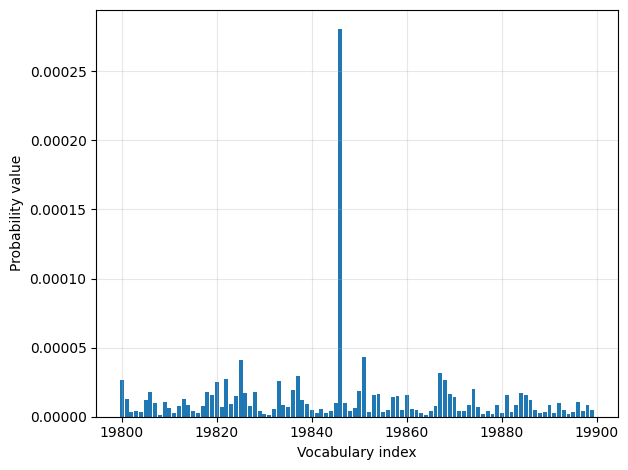

In [15]:
plot_scores_bar(
    next_token_probas, arrow=False, ylabel="Probability value"
)

In [16]:
print("Token ID 19,846 probability:", next_token_probas[:, 19846])

Token ID 19,846 probability: tensor([0.0003], dtype=torch.bfloat16)


In [17]:
print("Highest probability:", max(next_token_probas.squeeze(0)))

Highest probability: tensor(0.0003, dtype=torch.bfloat16)


In [18]:
# Step 3.4: Sample token according to probabilities
torch.manual_seed(123)
print(
    "Sampled token:",
    torch.multinomial(next_token_probas.cpu(), num_samples=1)
)

Sampled token: tensor([[65094]])


In [19]:
print(tokenizer.decode([65094]))

 mistress


In [20]:
def count_samples(probas, num_samples=1000, threshold=1, tokenizer=None):
    # Draw samples according to probabilities
    samples = torch.multinomial(
        probas.cpu(), num_samples=num_samples, replacement=True
    )
    
    # Count how often each index was selected
    counts = torch.bincount(samples.squeeze(0), minlength=1)
    
    # Print results
    for i, c in enumerate(counts):
        if c > threshold:
            if tokenizer is None:
                print(f"Vocab index {i}: {c.item()}x")
            else:
                print(f"'{tokenizer.decode([i])}': {c.item()}x")

In [21]:
torch.manual_seed(123)
count_samples(next_token_probas, tokenizer=tokenizer)

'}': 2x
' </': 2x
' represent': 2x
' Inf': 2x
'()*': 2x
' beside': 2x
' Kob': 2x
'�': 2x


In [22]:
torch.manual_seed(123)
probas_lowT = torch.softmax(
    scale_logits_by_temperature(next_token_logits, 0.35), dim=-1
)
count_samples(probas_lowT, threshold=1, tokenizer=tokenizer)

' __': 158x
' Berlin': 435x
' ____': 169x
' ______': 209x
' Munich': 3x
' Hamburg': 3x
' _____': 18x


In [23]:
print(probas_lowT[0, 19_846])

tensor(0.4199, dtype=torch.bfloat16)


- `"______"` 很可能是因为模型在训练集中见过类似的格式，并试图为用户生成一个测验

&nbsp;
### 4.4.4 在文本生成函数中添加温度缩放

In [24]:
# Exercise 2.2 Appendix B
from reasoning_from_scratch.qwen3 import KVCache

@torch.inference_mode()
def generate_text_temp_stream_cache(
    model,
    token_ids,
    max_new_tokens,
    eos_token_id=None,
    temperature=0.
):
    model.eval()
    cache = KVCache(n_layers=model.cfg["n_layers"])
    model.reset_kv_cache()

    # Step 3.1: Get logits
    out = model(token_ids, cache=cache)[:, -1]
    for _ in range(max_new_tokens):

        ########################################
        # NEW:
        orig_device = token_ids.device

        if temperature is None or temperature == 0.0:
            next_token = torch.argmax(out, dim=-1, keepdim=True)

        else:
            # Step 3.2: Apply temperature scaling on logits
            logits = scale_logits_by_temperature(out, temperature)

            # Step 3.3: Convert to probabilities
            probas = torch.softmax(logits, dim=-1)

            # Step 3.4: Sample token according to probabilities
            next_token = torch.multinomial(probas.cpu(), num_samples=1)
            next_token = next_token.to(orig_device)
            
        #########################################
        if (eos_token_id is not None
                and torch.all(next_token == eos_token_id)):
            break

        yield next_token
        out = model(next_token, cache=cache)[:, -1]

In [25]:
torch.manual_seed(123)
response = generate_text_stream_concat_flex(
    model, tokenizer, prompt, device,
    max_new_tokens=2048, verbose=True,
    generate_func=generate_text_temp_stream_cache,
    temperature=1.1
)

 \boxed{$x = \frac{90}{7}$}

&nbsp;
## 4.5 通过 top-p（核）采样平衡多样性与连贯性

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch04/CH04_F12_raschka.webp" width=600>

&nbsp;
### 4.5.1 选择 top-p 词元的子集

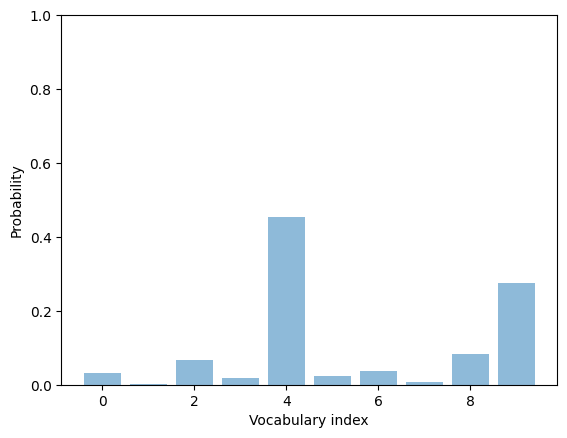

In [26]:
# Step 3.1: Get logits (here: use toy logits for 10 tokens)
toy_logits = torch.tensor(
    [-0.7, -3.0, 0.1, -1.2, 2.0, -1.0, -0.5, -2.0, 0.3, 1.5]
)

# Step 3.2: Apply temperature scaling
toy_logits_scaled = scale_logits_by_temperature(toy_logits, 1.0)

# Step 3.3: Convert to probabilities
toy_probas = torch.softmax(toy_logits_scaled, dim=-1)

plt.bar(
    torch.arange(len(toy_logits_scaled)), toy_probas,
    alpha=0.5
)

plt.ylim([0, 1])
plt.xlabel("Vocabulary index")
plt.ylabel("Probability")
# plt.savefig("12.pdf")
plt.show()

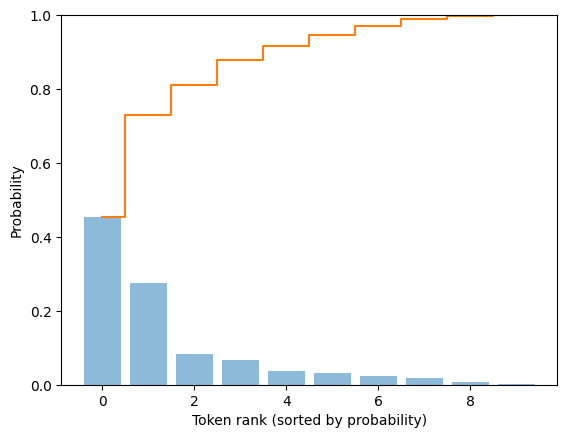

In [27]:
# Step 4.1: Sort by descending probability
sorted_probas, sorted_idx = torch.sort(toy_probas, descending=True)

# Step 4.2: Compute cumulative sum
cumsum = torch.cumsum(sorted_probas, dim=-1)

plt.bar(
    torch.arange(len(sorted_probas)), sorted_probas, 
        alpha=0.5
)
plt.step(
    torch.arange(len(cumsum)), cumsum, 
    where="mid", color="C1", label="Cumulative sum"
)

plt.ylim([0, 1])
plt.xlabel("Token rank (sorted by probability)")
plt.ylabel("Probability")
plt.show()

tensor([0.4538, 0.7290, 0.8119, 0.8798, 0.9170, 0.9475, 0.9701, 0.9886, 0.9969,
        1.0000])

In [45]:
# Step 4.3.1: Apply top-p threshold (e.g., keep tokens until cumulative mass > 0.8)
top_p = 0.8
keep_mask = cumsum <= top_p
n_kept = torch.sum(keep_mask).item()
print("Cumulative sum:", cumsum)
print("Tokens kept:", n_kept)

Cumulative sum: tensor([0.4538, 0.7290, 0.8119, 0.8798, 0.9170, 0.9475, 0.9701, 0.9886, 0.9969,
        1.0000])
Tokens kept: 2


In [47]:
# A more common variant is to include the token that crosses the threshold
keep_mask = (cumsum - sorted_probas) < top_p
n_kept = keep_mask.sum().item()
print("Tokens kept:", n_kept)

Tokens kept: 3


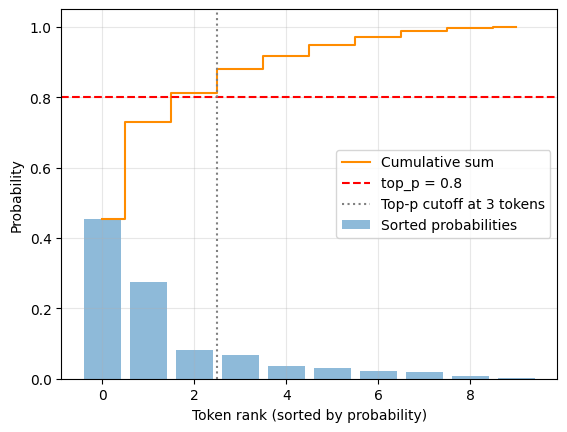

In [48]:
plt.bar(
    torch.arange(len(sorted_probas)), sorted_probas, 
    alpha=0.5, label="Sorted probabilities"
)
plt.step(
    torch.arange(len(cumsum)), cumsum, where="mid",
    color="darkorange", label="Cumulative sum"
)

# Highlight cutoff
plt.axhline(
    top_p, color="red", linestyle="--",
    label=f"top_p = {top_p}"
)
plt.axvline(
    n_kept - 0.5, color="gray", linestyle=":",
    label=f"Top-p cutoff at {n_kept} tokens"
)

plt.xlabel("Token rank (sorted by probability)")
plt.ylabel("Probability")
plt.legend()
plt.grid(alpha=0.3)
plt.ylim(0, 1.05)
# plt.savefig("14.pdf")
plt.show()

In [31]:
# Step 4.3.2: Zero out beyond cutoff
kept_sorted = torch.where(
    keep_mask, sorted_probas,
    torch.zeros_like(sorted_probas)
)

# Step 4.3.3: Map back to original order
filtered = torch.zeros_like(toy_probas).scatter(0, sorted_idx, kept_sorted)

print(filtered)

tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.4538, 0.0000, 0.0000, 0.0000, 0.0829,
        0.2752])


In [32]:
# Step 4.4: Renormalize to sum to 1
denom = torch.sum(filtered).clamp_min(1e-12)
renormalized = filtered / denom
print(renormalized)

tensor([0.0000, 0.0000, 0.0000, 0.0000, 0.5589, 0.0000, 0.0000, 0.0000, 0.1021,
        0.3390])


&nbsp;
### 4.5.2 在文本生成函数中添加 top-p 过滤

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch04/CH04_F16_raschka.webp" width=600 alt="图4-16">

In [33]:
def top_p_filter(probas, top_p):
    if top_p is None or top_p >= 1.0:
        return probas

    # Step 4.1: Sort by descending probability
    sorted_probas, sorted_idx = torch.sort(probas, dim=1, descending=True)

    # Step 4.2: Cumulative sum
    cumprobas = torch.cumsum(sorted_probas, dim=1)

    # Step 4.3.1: Keep tokens where prefix cumulative mass (before token) is < top_p
    # Example: [0.5, 0.41, 0.09] with top_p=0.9 should keep the first two tokens
    prefix = cumprobas - sorted_probas   # cumulative mass before each token
    keep = prefix < top_p
    # Always keep at least one token (fallback for very small/non-positive top_p)
    keep[:, 0] = True    

    # Step 4.3.2: Zero out beyond cutoff
    kept_sorted = torch.where(
        keep, sorted_probas,
        torch.zeros_like(sorted_probas)
    )
    # Step 4.3.3: Map back to original order
    filtered = torch.zeros_like(probas).scatter(1, sorted_idx, kept_sorted)

    # Step 4.4: Renormalize to sum to 1
    denom = torch.sum(filtered, dim=1, keepdim=True).clamp_min(1e-12)
    return filtered / denom

In [34]:
with torch.inference_mode():
    next_token_logits = model(input_token_ids)[:, -1]
print(next_token_logits.shape)

torch.Size([1, 151936])


In [35]:
torch.manual_seed(123)
probas_lowT = torch.softmax(
    scale_logits_by_temperature(next_token_logits, 0.35), dim=-1
)
count_samples(probas_lowT, threshold=1, tokenizer=tokenizer)

' __': 158x
' Berlin': 435x
' ____': 169x
' ______': 209x
' Munich': 3x
' Hamburg': 3x
' _____': 18x


In [36]:
torch.manual_seed(123)
probas_lowT = torch.softmax(
    scale_logits_by_temperature(next_token_logits, 0.35), dim=-1
)
probas_lowT_filtered = top_p_filter(probas_lowT, top_p=0.8)

count_samples(probas_lowT_filtered, threshold=1, tokenizer=tokenizer)

' Berlin': 534x
' ____': 217x
' ______': 249x


In [37]:
@torch.inference_mode()
def generate_text_top_p_stream_cache(
    model,
    token_ids,
    max_new_tokens,
    eos_token_id=None,
    temperature=0.,
    top_p=None
):
    model.eval()
    cache = KVCache(n_layers=model.cfg["n_layers"])
    model.reset_kv_cache()

    # Step 3.1: Get logits
    out = model(token_ids, cache=cache)[:, -1]
    for _ in range(max_new_tokens):

        orig_device = token_ids.device

        if temperature is None or temperature == 0.0:
            next_token = torch.argmax(out, dim=-1, keepdim=True)

        else:
            # Step 3.2: Apply temperature scaling on logits
            logits = scale_logits_by_temperature(out, temperature)

            # Step 3.3: Convert to probabilities
            probas = torch.softmax(logits, dim=-1)

            # (New) Step 4: Apply top-p filter to probabilities
            probas = top_p_filter(probas, top_p)            

            # Step 3.4: Sample token according to probabilities
            next_token = torch.multinomial(probas.cpu(), num_samples=1)
            next_token = next_token.to(orig_device)

        if (eos_token_id is not None
                and torch.all(next_token == eos_token_id)):
            break

        yield next_token
        out = model(next_token, cache=cache)[:, -1]

In [38]:
torch.manual_seed(123)
response = generate_text_stream_concat_flex(
    model, tokenizer, prompt, device,
    max_new_tokens=2048, verbose=True,
    generate_func=generate_text_top_p_stream_cache,
    temperature=0.5,
    top_p=0.8, 
)

 \boxed{18}

&nbsp;
## 4.6 通过自一致性提升响应准确性

- 通过采样和投票生成多个答案（/推理链）

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch04/CH04_F17_raschka.webp" width=600>

- 类似于经典的多数投票法，但使用不同的温度设置而非不同的模型
- 这种方法也在论文《自一致性提升语言模型中的思维链推理》(https://arxiv.org/abs/2203.11171) 中有所描述
- 简而言之，该方法
  - 使用高温度和 top-p 采样生成多个推理链
  - 从每条推理链中提取最终答案
  - 选择出现频率最高的最终答案
- 注意：这被称为复数投票 (Plurality voting)（美式英语），而非多数投票

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch04/CH04_F18_raschka.webp?1" width=600>

In [39]:
from reasoning_from_scratch.ch03 import extract_final_candidate
from collections import Counter

def self_consistency_vote(
    model, tokenizer, prompt, device,
    num_samples=10, temperature=0.8, top_p=0.9, max_new_tokens=2048,
    show_progress=True, show_long_answer=False, seed=None,
):
    full_answers, short_answers = [], []

    # 1) Sample multiple answers
    for i in range(num_samples):
        if seed is not None:
            torch.manual_seed(seed + i + 1)

        answer = generate_text_stream_concat_flex(
            model=model, tokenizer=tokenizer, prompt=prompt, device=device,
            max_new_tokens=max_new_tokens, verbose=show_long_answer,
            generate_func=generate_text_top_p_stream_cache,
            temperature=temperature, top_p=top_p,
        )

        # 2) Extract the final (short) answer from each answer
        short = extract_final_candidate(
            answer, fallback="number_then_full"
        )
        full_answers.append(answer)
        short_answers.append(short)
        if show_progress:
            print(f"[Sample {i+1}/{num_samples}] → {short!r}")

    # 3) Choose the most frequent final answer (self-consistency vote)
    counts = Counter(short_answers)
    groups = {s: [] for s in counts}
    for idx, s in enumerate(short_answers):
        groups[s].append(idx)

    mc = counts.most_common()
    if not mc:
        majority_winners, final_answer = [], None
    else:
        top_freq = mc[0][1]
        majority_winners = [s for s, f in mc if f == top_freq]
        final_answer = mc[0][0] if len(majority_winners) == 1 else None

    return {
        "full_answers": full_answers,
        "short_answers": short_answers,
        "counts": dict(counts),
        "groups": groups,
        "majority_winners": majority_winners,
        "final_answer": final_answer,
    }

- 额外提示
  - 如果所有（较长）回答看起来几乎相同，可适当提高温度以增加多样性
  - 如果（较长）回答看起来不对劲，请降低温度

In [40]:
results = self_consistency_vote(
    model,
    tokenizer,
    prompt,
    device=device,
    num_samples=5,
    temperature=0.8,
    top_p=0.9,
    max_new_tokens=2048,
    seed=123,
    show_progress=True,
)

[Sample 1/5] → '83'
[Sample 2/5] → '22'
[Sample 3/5] → '54'
[Sample 4/5] → '83'
[Sample 5/5] → '61'


In [41]:
print(results["final_answer"])

83


In [42]:
print(results["full_answers"][0])

 To find the value of \( x \), let's solve the equation step by step.

1. **Given Equation:**
   \[
   \frac{1}{2} \times (3x - 9) = x + 37
   \]

2. **Multiply Both Sides by 2 to Eliminate the Fraction:**
   \[
   2 \times \frac{1}{2} \times (3x - 9) = 2 \times (x + 37)
   \]
   \[
   3x - 9 = 2x + 74
   \]

3. **Subtract \( 2x \) from Both Sides to Get:**
   \[
   3x - 2x - 9 = 74
   \]
   \[
   x - 9 = 74
   \]

4. **Add 9 to Both Sides to Solve for \( x \):**
   \[
   x = 74 + 9
   \]
   \[
   x = 83
   \]

**Final Answer:**
\[
\boxed{83}
\]


In [43]:
results = self_consistency_vote(
    model,
    tokenizer,
    prompt + "\n\nExplain step by step.",
    device=device,
    num_samples=5,
    temperature=0.8,
    top_p=0.9,
    max_new_tokens=2048,
    seed=123,
    show_progress=True,
)

[Sample 1/5] → 'x = 83'
[Sample 2/5] → '83'
[Sample 3/5] → '83'
[Sample 4/5] → '83'
[Sample 5/5] → '83'


- 类似这样的并行采样也被 Claude 4 (https://www.anthropic.com/news/claude-4) 所采用；此外，Claude 4 还使用内部模型对响应进行评分
- 评分器可以类似于附录 F（F.5 使用其他 LLM 评判响应）中的 LLM 评判器
- 在下一章中，我们还将介绍一种基于置信度分数的评分方法（我们也可以将其用作决胜局）

以下是不同方法在CUDA设备（DGX Spark）上于完整MATH-500测试集（包含全部500道题目）的评估结果

|    | 方法                                       | 模型     | 准确率 | 时间       |
|----|----------------------------------------------|-----------|----------|------------|
| 1  | 基线（第3章），贪心解码        | 基础      | 15.2%    | 10.1 分钟   |
| 2  | 基线（第3章），贪心解码        | 推理 | 48.2%    | 182.1 分钟  |
| 3  | 思维链提示（"CoT"）           | 基础      | 40.6%    | 84.5 分钟   |
| 4  | 温度与top-p（"Top-p"）              | 基础      | 17.8%    | 30.7 分钟   |
| 5  | "Top-p" + 自一致性 (n=3)             | 基础      | 29.6%    | 97.6 分钟   |
| 6  | "Top-p" + 自一致性 (n=5)             | 基础      | 27.8%    | 116.8 分钟  |
| 7  | "Top-p" + 自一致性 (n=10)            | 基础      | 31.6%    | 300.4 分钟  |
| 8  | "Top-p" + "CoT"                              | 基础      | 33.4%    | 129.2 分钟  |
| 9  | 自一致性 (n=3) + "Top-p" + "CoT"     | 基础      | 42.2%    | 211.6 分钟  |
| 10 | 自一致性 (n=5) + "Top-p" + "CoT"     | 基础      | 48.0%    | 452.9 分钟  |
| 11 | 自一致性 (n=10) + "Top-p" + "CoT"    | 基础      | 52.0%    | 862.6 分钟  |
| 12 | 自一致性 (n=3) + "Top-p" + "CoT"     | 推理 | 55.2%    | 544.4 分钟  |

<img src="https://sebastianraschka.com/images/reasoning-from-scratch-images/ch04/CH04_F19_raschka.webp" width=600>

&nbsp;
## 4.7 总结

- 本节无代码